In [ ]:
# ------------------------------------------------------------
# STEP 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


# STEP 2: Load Dataset

df = pd.read_csv("/content/student_performance_dataset.csv")

print(df.head())
print(df.columns)


# STEP 3: Define Features and Target

X = df.drop("FinalScore", axis=1)
y = df["FinalScore"]

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)


   StudyTime  Attendance  SleepHours  PreviousScore InternetAccess  \
0          4          93           6             86            Yes   
1          5          65           7             60             No   
2          3          81           5             55            Yes   
3          5          70           6             93            Yes   
4          5          75           8             60             No   

  ExtraActivities ParentalEducation  FinalScore  
0              No            Master   71.524838  
1             Yes          Bachelor   59.287366  
2              No          Bachelor   55.222363  
3              No            Master   74.392758  
4              No          Bachelor   52.828560  
Index(['StudyTime', 'Attendance', 'SleepHours', 'PreviousScore',
       'InternetAccess', 'ExtraActivities', 'ParentalEducation', 'FinalScore'],
      dtype='object')


In [ ]:
# STEP 4: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 5: Build Model

model = DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
# STEP 6: Prediction & Evaluation

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 58.91095110313654
R2 Score: 0.5986102091773142


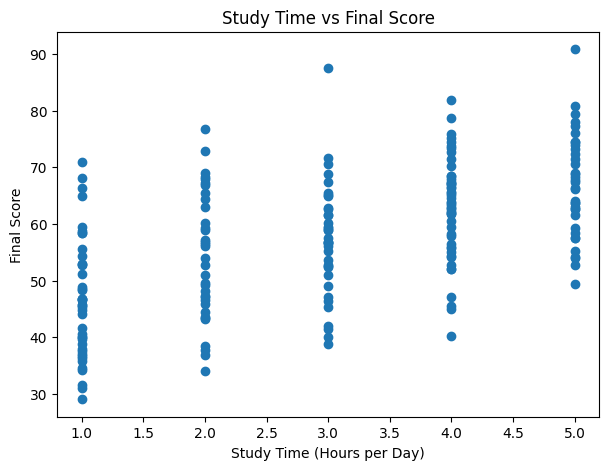

In [ ]:
#Scatter Plot: Study Time vs Final Score

plt.figure(figsize=(7,5))

plt.scatter(df["StudyTime"], df["FinalScore"])

plt.xlabel("Study Time (Hours per Day)")
plt.ylabel("Final Score")
plt.title("Study Time vs Final Score")

plt.show()

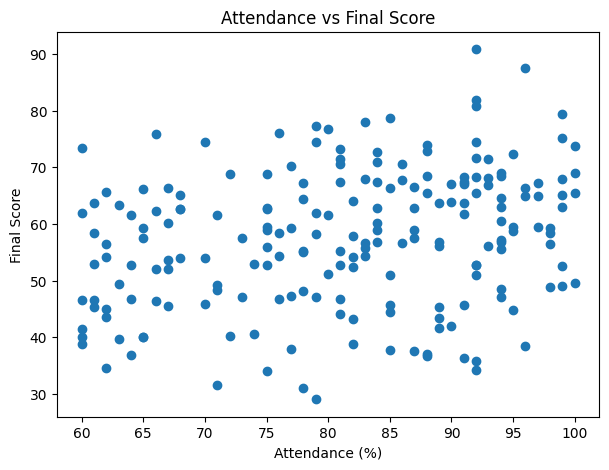

In [ ]:
#Scatter Plot: Attendance vs Final Score

plt.figure(figsize=(7,5))

plt.scatter(df["Attendance"], df["FinalScore"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.show()

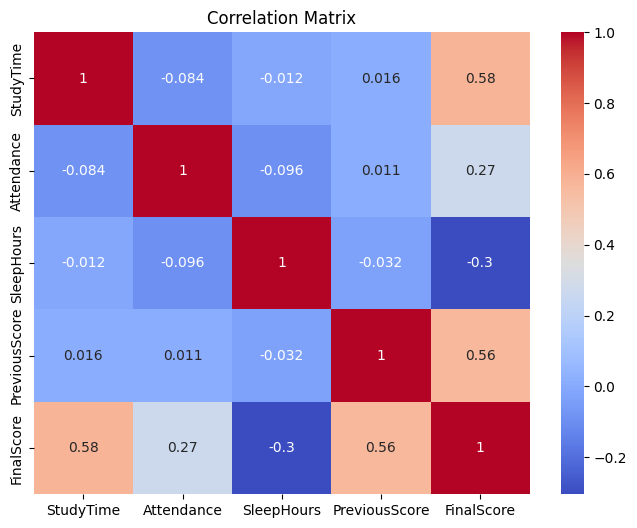

In [ ]:
#Seaborn: Correlation Heatmap

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

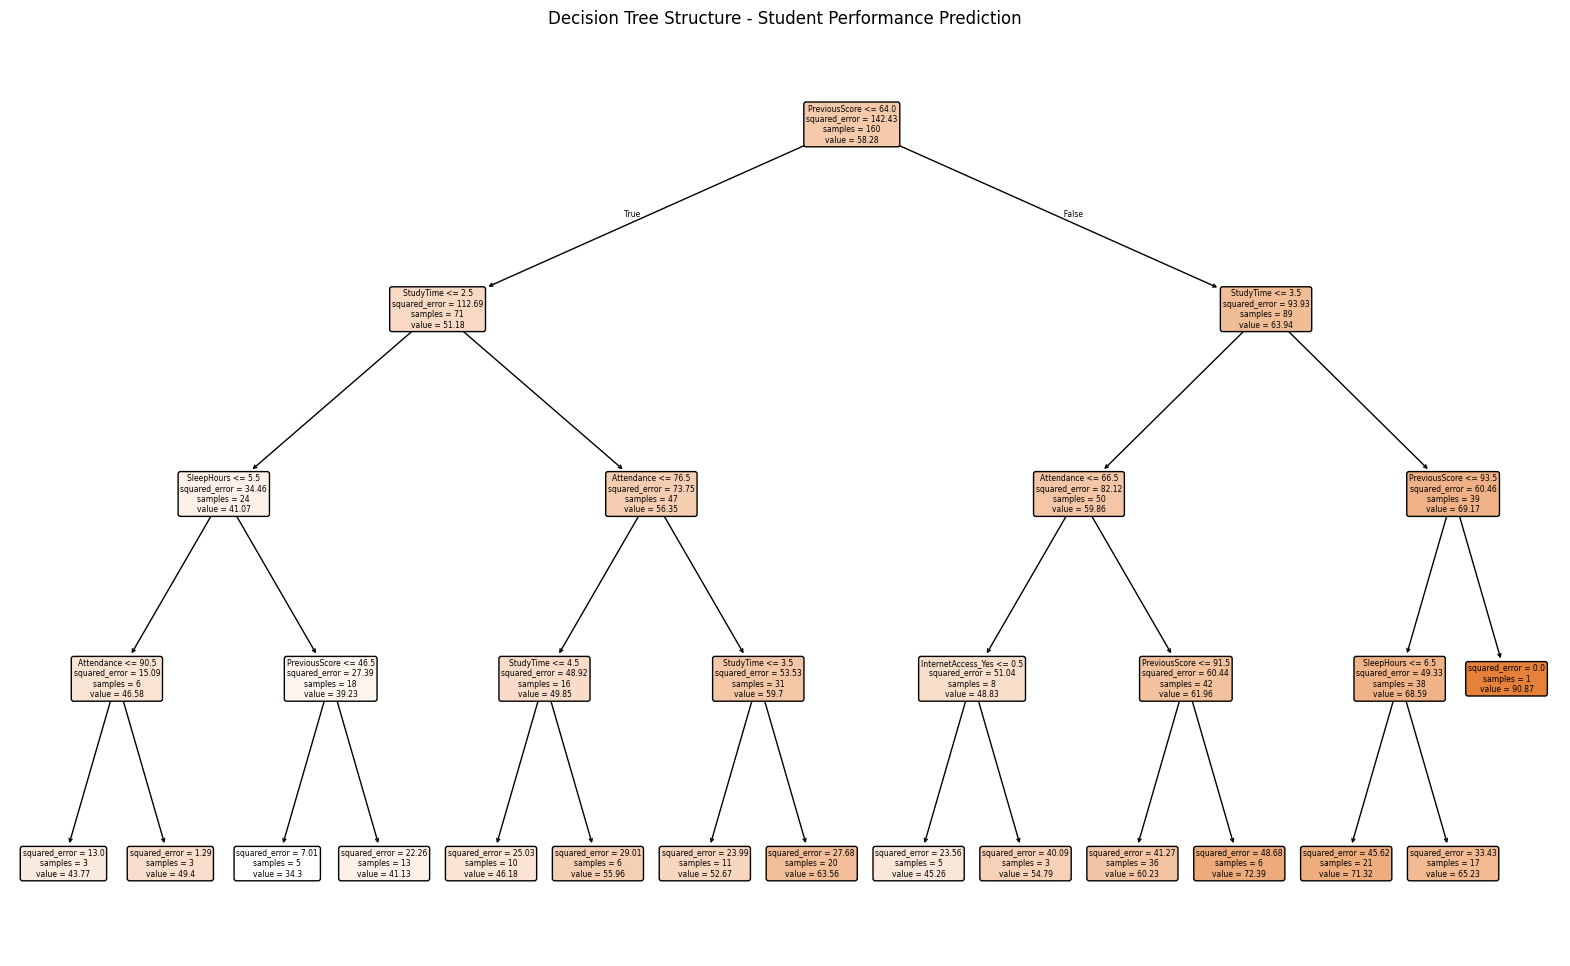

In [ ]:
#Decision Tree Structure - Student Performance Prediction

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12))

plot_tree(
    model,
    feature_names=X.columns,  # automatically matches features
    filled=True,
    rounded=True,
    precision=2
)

plt.title("Decision Tree Structure - Student Performance Prediction")
plt.show()